In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import requests
import unicodedata



In [56]:
from pysus.online_data import SINAN
metadata = SINAN.metadata_df('LEIV')
metadata.to_excel("data/metadata_LEIV.xlsx", index=False, freeze_panes=(1,0))


from pysus.ftp.databases.sinan import SINAN
sinan = SINAN().load()
arquivo = sinan.get_files('LEIV')
print (arquivo)

In [57]:
from pysus import SINAN
sinan = SINAN().load()
dados = sinan.download(sinan.get_files('LEIV', 2025))
df = dados.to_dataframe()

334996it [00:00, 44771853.00it/s]    


In [58]:
print ("== HEAD ==")
print (df.head())
print ("== SHAPE ==")
print (df.shape)
print ("== COLUMNS ==")
print (df.columns)
print ("== INFO ==")
df.info()

== HEAD ==
  TP_NOT ID_AGRAVO  DT_NOTIFIC SEM_NOT NU_ANO SG_UF_NOT ID_MUNICIP ID_REGIONA  \
0      2      B550  2025-01-01  202501   2025        50     500830   6255       
1      2      B550  2025-01-01  202501   2025        17     170210              
2      2      B550  2025-01-01  202501   2025        15     150140   1484       
3      2      B550  2025-01-01  202501   2025        50     500830   6255       
4      2      B550  2025-01-01  202501   2025        50     500270   1975       

  ID_UNIDADE  DT_SIN_PRI  ... DS_TRANS_1 DT_DESLC2 DS_MUN_2 CO_UF_2 CO_PAIS_2  \
0    2945622  2025-01-01  ...                                                   
1    3663051  2025-01-01  ...                                                   
2    2752700  2024-12-02  ...                                                   
3    2945622  2025-01-01  ...                                                   
4    0009733  2025-01-01  ...                                                   

  DS_TRANS_2 DT

In [59]:
colunas_categorias = df.nunique().sort_values()[df.nunique().sort_values() < 10].index
print (colunas_categorias)
colunas_nao_categorias = df.nunique().sort_values()[df.nunique().sort_values() >= 10].index
print (colunas_nao_categorias)

Index(['TP_NOT', 'ID_AGRAVO', 'MIGRADO_W', 'NU_ANO', 'FLXRECEBI', 'CS_FLXRET',
       'CO_PAIS_1', 'CS_SEXO', 'CO_PAIS_3', 'CO_PAIS_2', 'CRITERIO',
       'NDUPLIC_N', 'DIAG_PAR_N', 'TOSSE', 'PALIDEZ', 'BACO', 'INFECCIOSO',
       'FEN_HEMORR', 'ICTERICIA', 'HIV', 'EMAGRA', 'IFI', 'OUTRO', 'DOSE',
       'CLASSI_FIN', 'TPAUTOCTO', 'DOENCA_TRA', 'OUTROS', 'EDEMA', 'FIGADO',
       'FEBRE', 'FRAQUEZA', 'COPAISINF', 'FALENCIA', 'ENTRADA', 'ID_PAIS',
       'EVOLUCAO', 'CS_RACA', 'DROGA', 'CS_GESTANT', 'DS_TRANS_2',
       'DT_DESLC3'],
      dtype='object')
Index(['CO_UF_3', 'CS_ESCOL_N', 'CO_UF_2', 'DS_MUN_3', 'DS_TRANS_1',
       'DT_DESLC2', 'CO_UF_1', 'COUFINF', 'SG_UF_NOT', 'SG_UF', 'AMPOLAS',
       'SEM_NOT', 'DT_DESLC1', 'DS_MUN_2', 'DS_MUN_1', 'PESO', 'ANO_NASC',
       'NU_IDADE_N', 'SEM_PRI', 'DT_OBITO', 'ID_REGIONA', 'DT_DIGITA',
       'TRATAMENTO', 'DT_ENCERRA', 'ID_RG_RESI', 'DT_INVEST', 'DT_NOTIFIC',
       'ID_OCUPA_N', 'COMUNINF', 'DT_SIN_PRI', 'ID_MUNICIP', 'OUTROS_ESP'

In [60]:
for coluna in colunas_categorias:
    print(f"\n {'='*50}")
    print(f"Coluna: {coluna}")
    print(df[coluna].value_counts(dropna=False))


Coluna: TP_NOT
TP_NOT
2    6026
Name: count, dtype: Int64

Coluna: ID_AGRAVO
ID_AGRAVO
B550    6026
Name: count, dtype: Int64

Coluna: MIGRADO_W
MIGRADO_W
    6026
Name: count, dtype: Int64

Coluna: NU_ANO
NU_ANO
2025    6026
Name: count, dtype: Int64

Coluna: FLXRECEBI
FLXRECEBI
    6026
Name: count, dtype: Int64

Coluna: CS_FLXRET
CS_FLXRET
    6026
Name: count, dtype: Int64

Coluna: CO_PAIS_1
CO_PAIS_1
       5938
  1      88
Name: count, dtype: Int64

Coluna: CS_SEXO
CS_SEXO
M    3785
F    2241
Name: count, dtype: Int64

Coluna: CO_PAIS_3
CO_PAIS_3
       6009
  1      17
Name: count, dtype: Int64

Coluna: CO_PAIS_2
CO_PAIS_2
       5996
  1      29
199       1
Name: count, dtype: Int64

Coluna: CRITERIO
CRITERIO
      4899
1      954
2      173
Name: count, dtype: Int64

Coluna: NDUPLIC_N
NDUPLIC_N
     5993
1      32
0       1
Name: count, dtype: Int64

Coluna: DIAG_PAR_N
DIAG_PAR_N
3    4626
2     615
      429
1     356
Name: count, dtype: Int64

Coluna: TOSSE
TOSSE
2    3484


In [61]:
for coluna_naocategorica in colunas_nao_categorias:
    print(f"\n {'='*50}")
    print(f"Coluna: {coluna_naocategorica}")
    print(df[coluna_naocategorica].value_counts(dropna=False))


Coluna: CO_UF_3
CO_UF_3
      6009
31       6
35       3
52       2
42       1
53       1
50       1
23       1
22       1
51       1
Name: count, dtype: Int64

Coluna: CS_ESCOL_N
CS_ESCOL_N
09    1425
10    1006
06     844
03     585
01     486
       443
05     308
04     298
02     201
00     179
08     170
07      81
Name: count, dtype: Int64

Coluna: CO_UF_2
CO_UF_2
      5997
31      10
35       4
29       3
42       3
52       2
17       2
21       1
50       1
23       1
43       1
22       1
Name: count, dtype: Int64

Coluna: DS_MUN_3
DS_MUN_3
                                                                6010
310620                                                             5
353890                                                             1
521523                                                             1
520080                                                             1
420250                                                             1
530010                    

In [62]:
url_json_municipios = "https://raw.githubusercontent.com/kelvins/municipios-brasileiros/refs/heads/main/json/municipios.json"
url_json_uf = "https://raw.githubusercontent.com/kelvins/municipios-brasileiros/refs/heads/main/json/estados.json"

response_uf = requests.get(url_json_uf)
response_uf.encoding = "utf-8-sig"
df_uf = response_uf.json()

response_municipios = requests.get(url_json_municipios)
response_municipios.encoding = "utf-8-sig"
df_municipios = response_municipios.json()

estados_por_codigo = {estado["codigo_uf"]: estado for estado in df_uf}

estados_municipios = [
    (
        estados_por_codigo[municipio["codigo_uf"]]["uf"],
        municipio["codigo_uf"],
        municipio["nome"],
        municipio["codigo_ibge"],
    )
    for municipio in df_municipios
    if municipio["codigo_uf"] in estados_por_codigo
]
print (estados_municipios[:5])

[('GO', 52, 'Abadia de Goiás', 5200050), ('MG', 31, 'Abadia dos Dourados', 3100104), ('GO', 52, 'Abadiânia', 5200100), ('MG', 31, 'Abaeté', 3100203), ('PA', 15, 'Abaetetuba', 1500107)]


In [63]:
estados_por_codigo = {
    codigo_uf: uf
    for uf, codigo_uf, _, _ in estados_municipios
}

municipios_por_codigo = {
    str(codigo_ibge)[:-1]: (municipio, codigo_ibge)
    for _, _, municipio, codigo_ibge in estados_municipios
}

#normalizar dataframe

df['SG_UF_SIGLA'] = (
    df['SG_UF']
    .replace('', None)          
    .dropna()                 
    .astype(int)
    .map(estados_por_codigo)
)
df['NOME_MUNICIPIO']  = df['ID_MUNICIP'].astype(str).map(lambda x: municipios_por_codigo.get(x, (None, None))[0])
df['CODIGO_MUNICIPIO'] = df['ID_MUNICIP'].astype(str).map(lambda x: municipios_por_codigo.get(x, (None, None))[1])

df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], errors='coerce')

df['ANO_NOTIFIC'] = df['DT_NOTIFIC'].dt.year
df['MES_NOTIFIC'] = df['DT_NOTIFIC'].dt.month
df['DIA_NOTIFIC'] = df['DT_NOTIFIC'].dt.day
df['DT_OBITO'] = pd.to_datetime(df['DT_OBITO'], format='%Y%m%d', errors='coerce')

df['ANO_OBITO'] = df['DT_OBITO'].dt.year
df['MES_OBITO'] = df['DT_OBITO'].dt.month
df['DIA_OBITO'] = df['DT_OBITO'].dt.day

df.head()

,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,...,CO_PAIS_3,SG_UF_SIGLA,NOME_MUNICIPIO,CODIGO_MUNICIPIO,ANO_NOTIFIC,MES_NOTIFIC,DIA_NOTIFIC,ANO_OBITO,MES_OBITO,DIA_OBITO
0,2,B550,2025-01-01,202501,2025,50,500830,6255,2945622,2025-01-01,...,,MS,Três Lagoas,5008305,2025,1,1,NaN,NaN,NaN
1,2,B550,2025-01-01,202501,2025,17,170210,,3663051,2025-01-01,...,,TO,Araguaína,1702109,2025,1,1,NaN,NaN,NaN
2,2,B550,2025-01-01,202501,2025,15,150140,1484,2752700,2024-12-02,...,,PA,Belém,1501402,2025,1,1,NaN,NaN,NaN
3,2,B550,2025-01-01,202501,2025,50,500830,6255,2945622,2025-01-01,...,,MS,Três Lagoas,5008305,2025,1,1,NaN,NaN,NaN
4,2,B550,2025-01-01,202501,2025,50,500270,1975,0009733,2025-01-01,...,,MS,Campo Grande,5002704,2025,1,1,NaN,NaN,NaN


In [64]:
maps = {
    "CS_SEXO": {
        "M": "Masculino",
        "F": "Feminino",
    },
    "EVOLUCAO": {
        1: "Cura",
        2: "Abandono",
        3: "Obito por LeishManiose",
        4: "Obito por outras causas",
        5: "Transferência"
    },
    "DROGA": {
        1: "Antimonial Pentavalente",
        2: "Anfotericina B",
        3: "Pentamidina",
        4: "Anfotericina B Lipossomal",
        5: "Outras",
        6: "Sem drogas"
    },
    "CLASSI_FIN": {
        1: "Confirmado",
        2: "Descartado",
        8: "Inconclusivo"
    },
    "DIAG_PAR_N": {
        1: "Positivo",
        2: "Negativo",
        3: "Não realizado",
    }
}

pd.set_option('future.no_silent_downcasting', True)

for coluna, mapa in maps.items():
    chaves = list(mapa.keys())
    if isinstance(chaves[0], str):
        df[coluna] = df[coluna].str.strip().map(mapa).fillna(df[coluna])
    else:
        mapa_str = {str(k): v for k, v in mapa.items()}
        df[coluna] = df[coluna].astype(str).str.strip().map(mapa_str).fillna(df[coluna])

print(df[list(maps.keys())].head())

     CS_SEXO  EVOLUCAO       DROGA  CLASSI_FIN     DIAG_PAR_N
0   Feminino      Cura              Descartado  Não realizado
1   Feminino  Abandono  Sem drogas  Descartado  Não realizado
2   Feminino                        Confirmado       Positivo
3  Masculino      Cura              Descartado  Não realizado
4  Masculino      Cura              Descartado  Não realizado


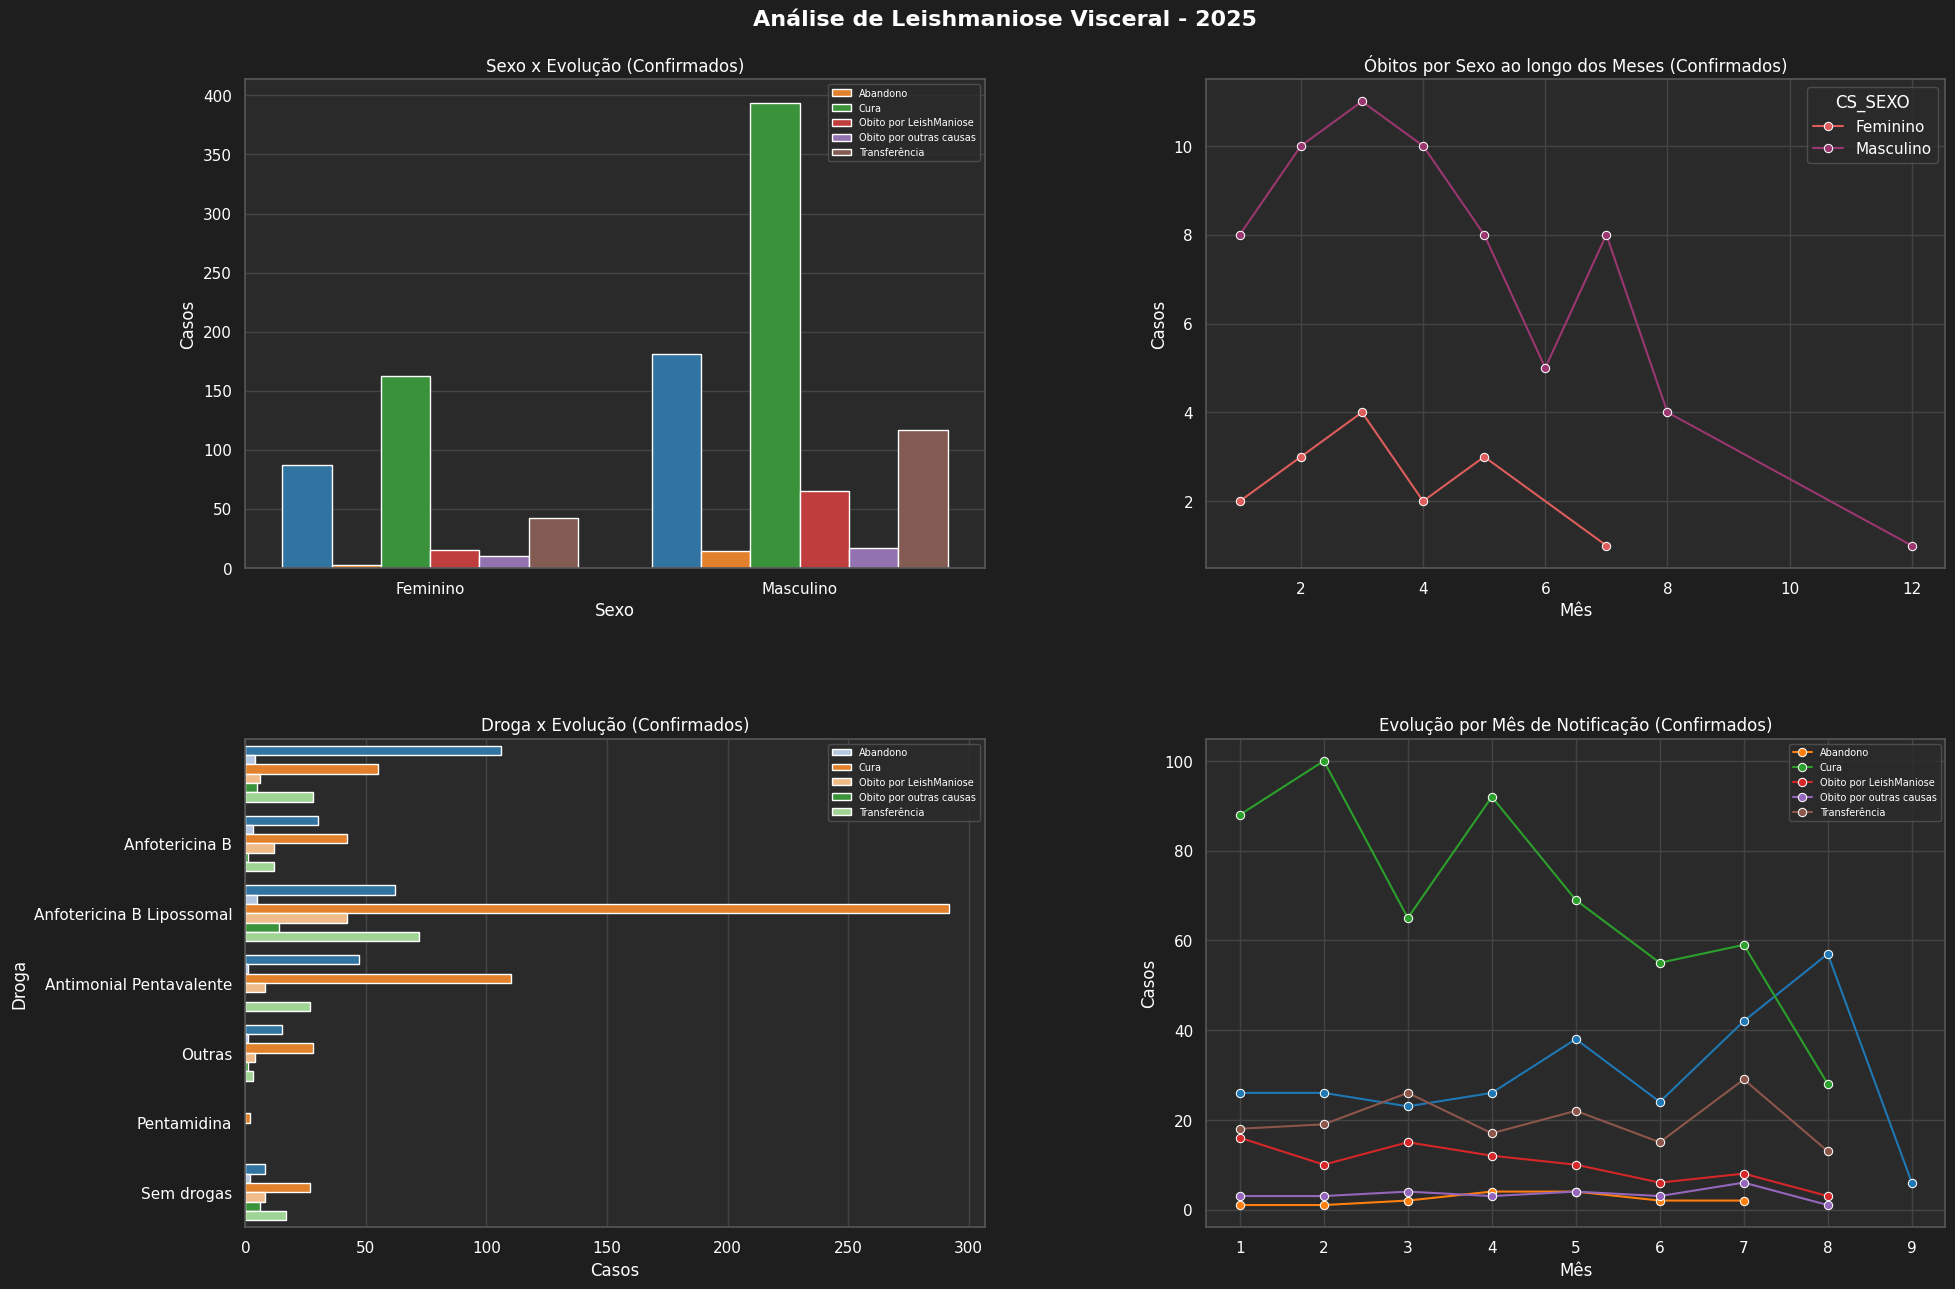

In [65]:
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#1e1e1e',
    'axes.facecolor': '#2a2a2a',
    'axes.edgecolor': '#555555',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'grid.color': '#444444',
    'legend.facecolor': '#2a2a2a',
    'legend.edgecolor': '#555555',
})

df_confirmado = df[df['CLASSI_FIN'] == 'Confirmado'].copy()

fig, axes = plt.subplots(2, 2, figsize=(20, 14), facecolor='#1e1e1e')
fig.suptitle('Análise de Leishmaniose Visceral - 2025', fontsize=16,
             fontweight='bold', color='white')

# 1. Sexo x Evolução (confirmados)
sexo_evolucao = df_confirmado.groupby(['CS_SEXO', 'EVOLUCAO']).size().reset_index(name='Casos')
sns.barplot(data=sexo_evolucao, x='CS_SEXO', y='Casos', hue='EVOLUCAO',
            ax=axes[0, 0], palette='tab10')
axes[0, 0].set_title('Sexo x Evolução (Confirmados)')
axes[0, 0].set_xlabel('Sexo')
axes[0, 0].legend(fontsize=7, loc='upper right')

# 2. Óbitos por Sexo ao longo dos Meses
obitos_sexo = df_confirmado[
    df_confirmado['EVOLUCAO'] == 'Obito por LeishManiose'
].groupby(['CS_SEXO', 'MES_OBITO']).size().reset_index(name='Casos')
sns.lineplot(data=obitos_sexo, x='MES_OBITO', y='Casos', hue='CS_SEXO',
             ax=axes[0, 1], palette='flare', marker='o')
axes[0, 1].set_title('Óbitos por Sexo ao longo dos Meses (Confirmados)')
axes[0, 1].set_xlabel('Mês')

# 3. Droga x Evolução
droga_evolucao = df_confirmado.groupby(['DROGA', 'EVOLUCAO']).size().reset_index(name='Casos')
sns.barplot(data=droga_evolucao, x='Casos', y='DROGA', hue='EVOLUCAO',
            ax=axes[1, 0], palette='tab20')
axes[1, 0].set_title('Droga x Evolução (Confirmados)')
axes[1, 0].set_ylabel('Droga')
axes[1, 0].legend(fontsize=7, loc='upper right')

# 4. Evolução por Mês
evolucao_mes = df_confirmado.groupby(['MES_NOTIFIC', 'EVOLUCAO']).size().reset_index(name='Casos')
sns.lineplot(data=evolucao_mes, x='MES_NOTIFIC', y='Casos', hue='EVOLUCAO',
             ax=axes[1, 1], palette='tab10', marker='o')
axes[1, 1].set_title('Evolução por Mês de Notificação (Confirmados)')
axes[1, 1].set_xlabel('Mês')
axes[1, 1].legend(fontsize=7, loc='upper right')

plt.subplots_adjust(top=0.93, hspace=0.35, wspace=0.3, left=0.12, right=0.97)
plt.savefig('analise_leishmaniose_completa.png', dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

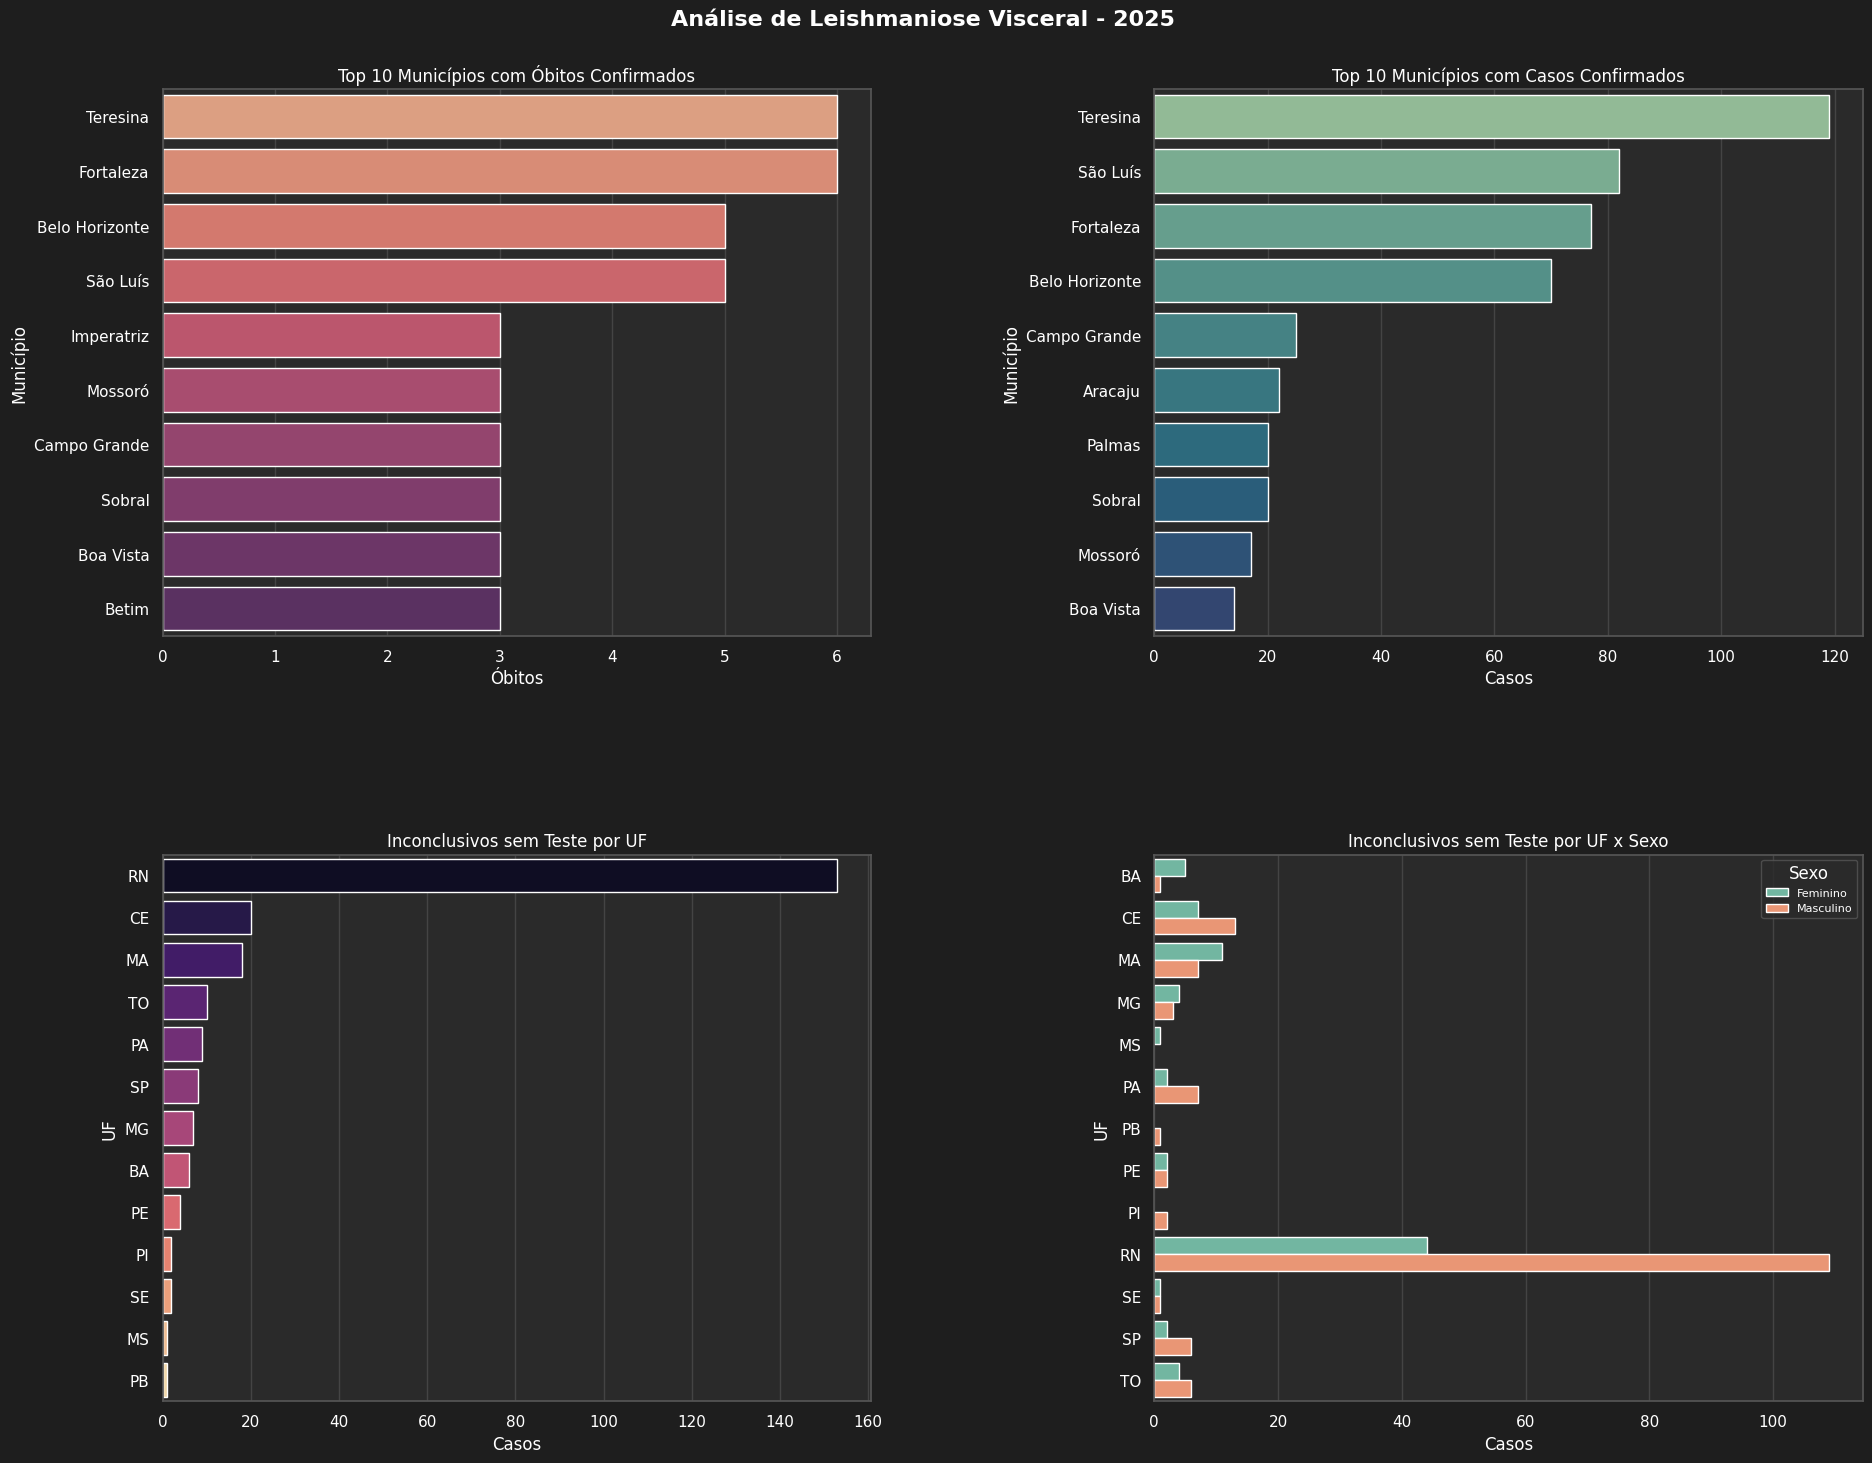

In [66]:
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#1e1e1e',
    'axes.facecolor': '#2a2a2a',
    'axes.edgecolor': '#555555',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'grid.color': '#444444',
    'legend.facecolor': '#2a2a2a',
    'legend.edgecolor': '#555555',
})

df_confirmado = df[df['CLASSI_FIN'] == 'Confirmado'].copy()
df_inconclusivo_sem_teste = df[
    (df['CLASSI_FIN'] == 'Inconclusivo') & 
    (df['DIAG_PAR_N'] == 'Não realizado')
].copy()

fig, axes = plt.subplots(2, 2, figsize=(20, 16), facecolor='#1e1e1e')
fig.suptitle('Análise de Leishmaniose Visceral - 2025', fontsize=16,
             fontweight='bold', color='white')

# 1. Top 10 Municípios com óbitos confirmados
mun_obitos = df_confirmado[
    df_confirmado['EVOLUCAO'] == 'Obito por LeishManiose'
]['NOME_MUNICIPIO'].value_counts().head(10).reset_index()
mun_obitos.columns = ['Município', 'Óbitos']
sns.barplot(data=mun_obitos, x='Óbitos', y='Município', hue='Município',
            ax=axes[0, 0], palette='flare', legend=False)
axes[0, 0].set_title('Top 10 Municípios com Óbitos Confirmados')
axes[0, 0].set_xlabel('Óbitos')

# 2. Top 10 Municípios com casos confirmados
mun_confirmados = df_confirmado['NOME_MUNICIPIO'].value_counts().head(10).reset_index()
mun_confirmados.columns = ['Município', 'Casos']
sns.barplot(data=mun_confirmados, x='Casos', y='Município', hue='Município',
            ax=axes[0, 1], palette='crest', legend=False)
axes[0, 1].set_title('Top 10 Municípios com Casos Confirmados')
axes[0, 1].set_xlabel('Casos')

# 3. Inconclusivos sem teste por UF
inc_uf = df_inconclusivo_sem_teste['SG_UF_SIGLA'].value_counts().reset_index()
inc_uf.columns = ['UF', 'Casos']
sns.barplot(data=inc_uf, x='Casos', y='UF', hue='UF',
            ax=axes[1, 0], palette='magma', legend=False)
axes[1, 0].set_title('Inconclusivos sem Teste por UF')
axes[1, 0].set_xlabel('Casos')

# 4. Inconclusivos sem teste por UF x Sexo
inc_sexo_uf = df_inconclusivo_sem_teste.groupby(['SG_UF_SIGLA', 'CS_SEXO']).size().reset_index(name='Casos')
sns.barplot(data=inc_sexo_uf, x='Casos', y='SG_UF_SIGLA', hue='CS_SEXO',
            ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Inconclusivos sem Teste por UF x Sexo')
axes[1, 1].set_ylabel('UF')
axes[1, 1].set_xlabel('Casos')
axes[1, 1].legend(title='Sexo', fontsize=8)

plt.subplots_adjust(top=0.93, hspace=0.4, wspace=0.4, left=0.12, right=0.97)
plt.savefig('analise_leishmaniose_completa2.png', dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

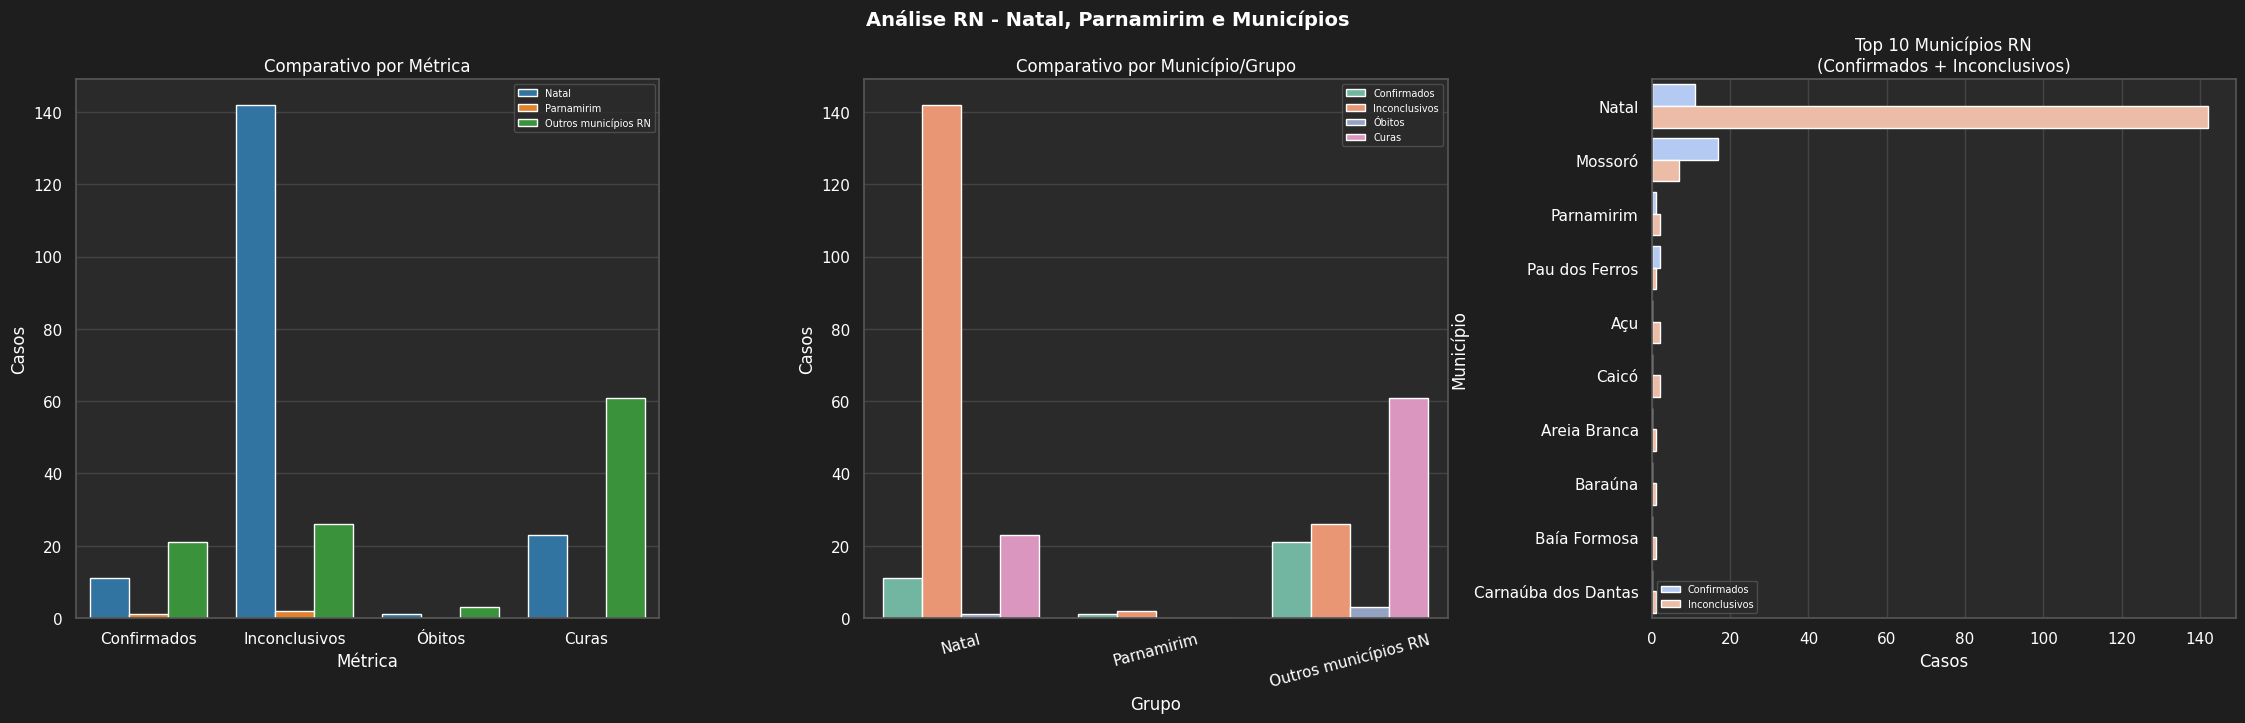

In [67]:
df_rn_todos = df[df['SG_UF_SIGLA'] == 'RN'].copy()

# top 10 municípios RN por confirmados + inconclusivos
top_rn = df_rn_todos.groupby('NOME_MUNICIPIO').agg(
    Confirmados=('CLASSI_FIN', lambda x: (x == 'Confirmado').sum()),
    Inconclusivos=('CLASSI_FIN', lambda x: (x == 'Inconclusivo').sum()),
).reset_index()
top_rn['Total'] = top_rn['Confirmados'] + top_rn['Inconclusivos']
top_rn = top_rn.nlargest(10, 'Total').drop(columns='Total')
top_rn_melted = top_rn.melt(id_vars='NOME_MUNICIPIO', var_name='Métrica', value_name='Casos')

# comparativo natal/parnamirim vs outros
grupos_rn = {
    'Natal': df_rn_todos['NOME_MUNICIPIO'].eq('Natal'),
    'Parnamirim': df_rn_todos['NOME_MUNICIPIO'].eq('Parnamirim'),
    'Outros municípios RN': ~df_rn_todos['NOME_MUNICIPIO'].isin(['Natal', 'Parnamirim']),
}

df_comp = pd.DataFrame([
    {
        'Grupo': grupo,
        'Confirmados': df_rn_todos.loc[filtro, 'CLASSI_FIN'].eq('Confirmado').sum(),
        'Inconclusivos': df_rn_todos.loc[filtro, 'CLASSI_FIN'].eq('Inconclusivo').sum(),
        'Óbitos': df_rn_todos.loc[filtro, 'EVOLUCAO'].eq('Obito por LeishManiose').sum(),
        'Curas': df_rn_todos.loc[filtro, 'EVOLUCAO'].eq('Cura').sum(),
    }
    for grupo, filtro in grupos_rn.items()
])

df_comp_melted = df_comp.melt(id_vars='Grupo',
                              value_vars=['Confirmados', 'Inconclusivos', 'Óbitos', 'Curas'],
                              var_name='Métrica', value_name='Casos')

fig, axes = plt.subplots(1, 3, figsize=(24, 7), facecolor='#1e1e1e')
for ax in axes:
    ax.set_facecolor('#2a2a2a')

fig.suptitle('Análise RN - Natal, Parnamirim e Municípios', 
             fontsize=14, fontweight='bold', color='white')

# 1. Comparativo por Métrica
sns.barplot(data=df_comp_melted, x='Métrica', y='Casos', hue='Grupo',
            ax=axes[0], palette='tab10')
axes[0].set_title('Comparativo por Métrica')
axes[0].set_xlabel('Métrica')
axes[0].set_ylabel('Casos')
axes[0].legend(fontsize=7)

# 2. Comparativo por Grupo
sns.barplot(data=df_comp_melted, x='Grupo', y='Casos', hue='Métrica',
            ax=axes[1], palette='Set2')
axes[1].set_title('Comparativo por Município/Grupo')
axes[1].set_xlabel('Grupo')
axes[1].set_ylabel('Casos')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(fontsize=7)

# 3. Top 10 Municípios RN
sns.barplot(data=top_rn_melted, x='Casos', y='NOME_MUNICIPIO', hue='Métrica',
            ax=axes[2], palette='coolwarm')
axes[2].set_title('Top 10 Municípios RN\n(Confirmados + Inconclusivos)')
axes[2].set_ylabel('Município')
axes[2].set_xlabel('Casos')
axes[2].legend(fontsize=7)

plt.subplots_adjust(top=0.88, wspace=0.35, left=0.07, right=0.97)
plt.savefig('comparativo_rn_completo.png', dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

In [69]:
resp_estados = requests.get('https://servicodados.ibge.gov.br/api/v1/localidades/estados')
estados_ibge = resp_estados.json()
regioes = {e['sigla']: e['regiao']['nome'] for e in estados_ibge}

def normaliza(texto):
    if not isinstance(texto, str):
        return ''
    return unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode().strip().upper()

capitais_norm = {
    'AC': 'RIO BRANCO',     'AL': 'MACEIO',          'AM': 'MANAUS',
    'AP': 'MACAPA',         'BA': 'SALVADOR',         'CE': 'FORTALEZA',
    'DF': 'BRASILIA',       'ES': 'VITORIA',          'GO': 'GOIANIA',
    'MA': 'SAO LUIS',       'MG': 'BELO HORIZONTE',   'MS': 'CAMPO GRANDE',
    'MT': 'CUIABA',         'PA': 'BELEM',            'PB': 'JOAO PESSOA',
    'PE': 'RECIFE',         'PI': 'TERESINA',         'PR': 'CURITIBA',
    'RJ': 'RIO DE JANEIRO', 'RN': 'NATAL',            'RO': 'PORTO VELHO',
    'RR': 'BOA VISTA',      'RS': 'PORTO ALEGRE',     'SC': 'FLORIANOPOLIS',
    'SE': 'ARACAJU',        'SP': 'SAO PAULO',        'TO': 'PALMAS',
}
# DADOS PNUD 2021 (base 2019)
idh = {
    'AC': 0.714, 'AL': 0.683, 'AM': 0.708, 'AP': 0.708, 'BA': 0.714,
    'CE': 0.715, 'DF': 0.814, 'ES': 0.740, 'GO': 0.756, 'MA': 0.676,
    'MG': 0.751, 'MS': 0.756, 'MT': 0.757, 'PA': 0.698, 'PB': 0.707,
    'PE': 0.715, 'PI': 0.695, 'PR': 0.769, 'RJ': 0.761, 'RN': 0.720,
    'RO': 0.725, 'RR': 0.707, 'RS': 0.778, 'SC': 0.792, 'SE': 0.720,
    'SP': 0.783, 'TO': 0.721,
}

df['REGIAO']    = df['SG_UF_SIGLA'].map(regioes)
df['IDH']       = df['SG_UF_SIGLA'].map(idh)
df['É_CAPITAL'] = df.apply(
    lambda row: normaliza(row['NOME_MUNICIPIO']) == capitais_norm.get(row['SG_UF_SIGLA'], ''),
    axis=1
)

print(df[['SG_UF_SIGLA', 'NOME_MUNICIPIO', 'REGIAO', 'IDH', 'É_CAPITAL']].head(10))
print(f"\nCapitais encontradas: {df['É_CAPITAL'].sum()} registros")
print(f"Regiões únicas: {df['REGIAO'].unique()}")
print(f"\nCapitais com casos:")
print(df[df['É_CAPITAL'] == True][['SG_UF_SIGLA', 'NOME_MUNICIPIO']].value_counts())

  SG_UF_SIGLA         NOME_MUNICIPIO        REGIAO    IDH  É_CAPITAL
0          MS            Três Lagoas  Centro-Oeste  0.756      False
1          TO              Araguaína         Norte  0.721      False
2          PA                  Belém         Norte  0.698       True
3          MS            Três Lagoas  Centro-Oeste  0.756      False
4          MS           Campo Grande  Centro-Oeste  0.756       True
5          PA  Conceição do Araguaia         Norte  0.698      False
6          MG         Belo Horizonte       Sudeste  0.751       True
7          SP          Montes Claros       Sudeste  0.783      False
8          PE              Salgueiro      Nordeste  0.715      False
9          TO                 Palmas         Norte  0.721       True

Capitais encontradas: 2332 registros
Regiões únicas: ['Centro-Oeste' 'Norte' 'Sudeste' 'Nordeste' 'Sul' nan]

Capitais com casos:
SG_UF_SIGLA  NOME_MUNICIPIO
CE           Fortaleza         412
MG           Belo Horizonte    322
MA          

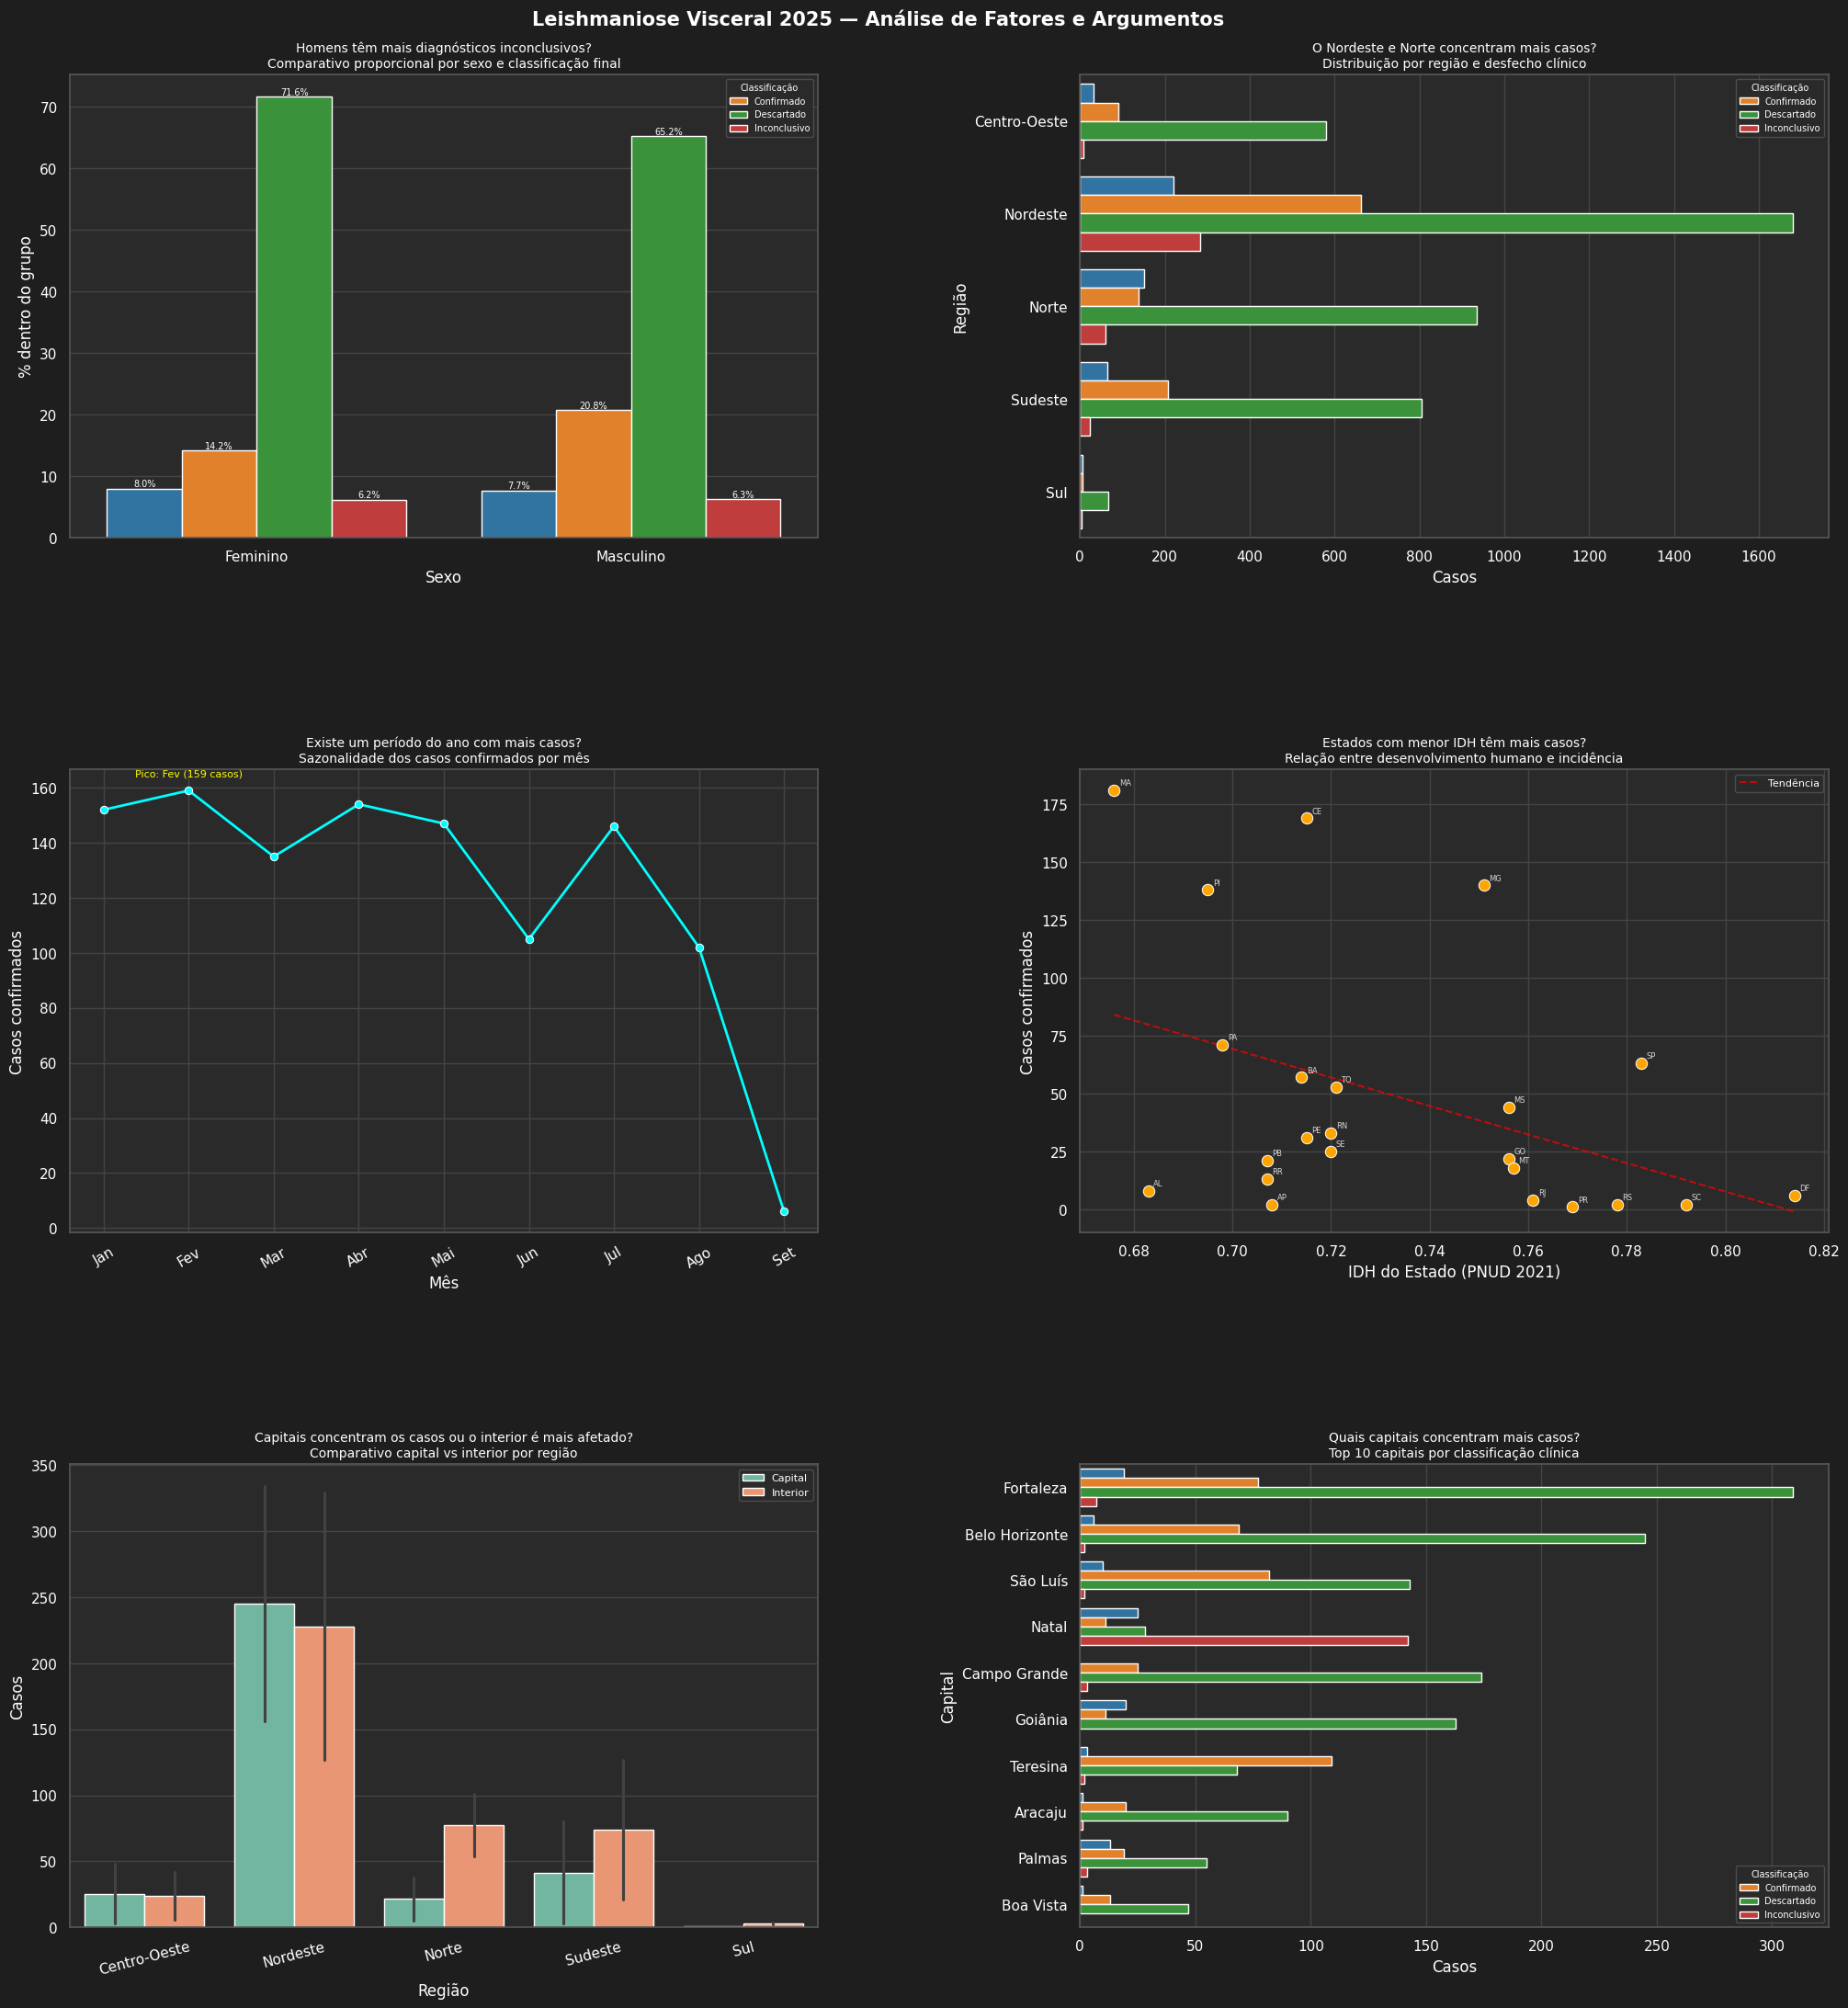

In [70]:
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#1e1e1e',
    'axes.facecolor': '#2a2a2a',
    'axes.edgecolor': '#555555',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'grid.color': '#444444',
    'legend.facecolor': '#2a2a2a',
    'legend.edgecolor': '#555555',
})

fig, axes = plt.subplots(3, 2, figsize=(22, 24), facecolor='#1e1e1e')
for ax in axes.flat:
    ax.set_facecolor('#2a2a2a')

fig.suptitle('Leishmaniose Visceral 2025 — Análise de Fatores e Argumentos',
             fontsize=15, fontweight='bold', color='white')

sexo_desfecho = df.groupby(['CS_SEXO', 'CLASSI_FIN']).size().reset_index(name='Casos')
sexo_desfecho = sexo_desfecho[sexo_desfecho['CS_SEXO'].isin(['Masculino', 'Feminino'])]

total_sexo = sexo_desfecho.groupby('CS_SEXO')['Casos'].transform('sum')
sexo_desfecho['Percentual'] = (sexo_desfecho['Casos'] / total_sexo * 100).round(1)

sns.barplot(data=sexo_desfecho, x='CS_SEXO', y='Percentual', hue='CLASSI_FIN',
            ax=axes[0, 0], palette='tab10')
axes[0, 0].set_title(
    'Homens têm mais diagnósticos inconclusivos?\n'
    'Comparativo proporcional por sexo e classificação final',
    color='white', fontsize=10
)
axes[0, 0].set_xlabel('Sexo')
axes[0, 0].set_ylabel('% dentro do grupo')
axes[0, 0].legend(fontsize=7, title='Classificação', title_fontsize=7)

for p in axes[0, 0].patches:
    h = p.get_height()
    if h > 1:
        axes[0, 0].annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2, h + 0.3),
                            ha='center', fontsize=7, color='white')

regiao_desfecho = df[df['REGIAO'].notna()].groupby(['REGIAO', 'CLASSI_FIN']).size().reset_index(name='Casos')

sns.barplot(data=regiao_desfecho, x='Casos', y='REGIAO', hue='CLASSI_FIN',
            ax=axes[0, 1], palette='tab10')
axes[0, 1].set_title(
    'O Nordeste e Norte concentram mais casos?\n'
    'Distribuição por região e desfecho clínico',
    color='white', fontsize=10
)
axes[0, 1].set_xlabel('Casos')
axes[0, 1].set_ylabel('Região')
axes[0, 1].legend(fontsize=7, title='Classificação', title_fontsize=7)

meses_nome = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
              7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}

sazon = df[df['CLASSI_FIN'] == 'Confirmado'].groupby('MES_NOTIFIC').size().reset_index(name='Casos')
sazon['MES_NOME'] = sazon['MES_NOTIFIC'].map(meses_nome)

sns.lineplot(data=sazon, x='MES_NOME', y='Casos',
             ax=axes[1, 0], color='cyan', marker='o', linewidth=2)
axes[1, 0].set_title(
    'Existe um período do ano com mais casos?\n'
    'Sazonalidade dos casos confirmados por mês',
    color='white', fontsize=10
)
axes[1, 0].set_xlabel('Mês')
axes[1, 0].set_ylabel('Casos confirmados')
axes[1, 0].tick_params(axis='x', rotation=30)

pico = sazon.loc[sazon['Casos'].idxmax()]
axes[1, 0].annotate(f"Pico: {pico['MES_NOME']} ({int(pico['Casos'])} casos)",
                    xy=(pico['MES_NOME'], pico['Casos']),
                    xytext=(pico['MES_NOME'], pico['Casos'] + 5),
                    color='yellow', fontsize=8, ha='center')

idh_casos = df[df['CLASSI_FIN'] == 'Confirmado'].groupby('SG_UF_SIGLA').agg(
    Casos=('CLASSI_FIN', 'count'),
    IDH=('IDH', 'first')
).reset_index()

sns.scatterplot(data=idh_casos, x='IDH', y='Casos', ax=axes[1, 1],
                color='orange', s=80, zorder=5)

import numpy as np
z = np.polyfit(idh_casos['IDH'], idh_casos['Casos'], 1)
p = np.poly1d(z)
x_line = np.linspace(idh_casos['IDH'].min(), idh_casos['IDH'].max(), 100)
axes[1, 1].plot(x_line, p(x_line), color='red', linestyle='--', alpha=0.7, label='Tendência')

for _, row in idh_casos.iterrows():
    axes[1, 1].annotate(row['SG_UF_SIGLA'],
                        (row['IDH'], row['Casos']),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=6, color='white', alpha=0.8)

axes[1, 1].set_title(
    'Estados com menor IDH têm mais casos?\n'
    'Relação entre desenvolvimento humano e incidência',
    color='white', fontsize=10
)
axes[1, 1].set_xlabel('IDH do Estado (PNUD 2021)')
axes[1, 1].set_ylabel('Casos confirmados')
axes[1, 1].legend(fontsize=8)

capital_comp = df[df['CLASSI_FIN'].isin(['Confirmado', 'Inconclusivo'])].copy()
capital_comp['Local'] = capital_comp['É_CAPITAL'].map({True: 'Capital', False: 'Interior'})
capital_regiao = capital_comp.groupby(['REGIAO', 'Local', 'CLASSI_FIN']).size().reset_index(name='Casos')
capital_regiao = capital_regiao[capital_regiao['REGIAO'].notna()]

sns.barplot(data=capital_regiao, x='REGIAO', y='Casos', hue='Local',
            ax=axes[2, 0], palette='Set2')
axes[2, 0].set_title(
    'Capitais concentram os casos ou o interior é mais afetado?\n'
    'Comparativo capital vs interior por região',
    color='white', fontsize=10
)
axes[2, 0].set_xlabel('Região')
axes[2, 0].set_ylabel('Casos')
axes[2, 0].tick_params(axis='x', rotation=15)
axes[2, 0].legend(fontsize=8)

top_capitais = df[df['É_CAPITAL'] == True].groupby(['NOME_MUNICIPIO', 'CLASSI_FIN']).size().reset_index(name='Casos')
top_municipios = df[df['É_CAPITAL'] == True]['NOME_MUNICIPIO'].value_counts().head(10).index
top_capitais = top_capitais[top_capitais['NOME_MUNICIPIO'].isin(top_municipios)]

sns.barplot(data=top_capitais, x='Casos', y='NOME_MUNICIPIO', hue='CLASSI_FIN',
            ax=axes[2, 1], palette='tab10',
            order=top_municipios)
axes[2, 1].set_title(
    'Quais capitais concentram mais casos?\n'
    'Top 10 capitais por classificação clínica',
    color='white', fontsize=10
)
axes[2, 1].set_xlabel('Casos')
axes[2, 1].set_ylabel('Capital')
axes[2, 1].legend(fontsize=7, title='Classificação', title_fontsize=7)

plt.subplots_adjust(top=0.95, hspace=0.5, wspace=0.35, left=0.1, right=0.97)
plt.savefig('argumentos_leishmaniose.png', dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()